In [30]:
import pathlib
import numpy as np
import scipy as sp
from matplotlib import pyplot as plt
from matplotlib import gridspec
import pandas as pd
import pingouin as pg
import seaborn as sns


import TwoPUtils as tpu
import STX3KO_analyses as stx
from STX3KO_analyses import utilities as u

ko_mice = stx.ymaze_sess_deets.ko_mice
ctrl_mice = stx.ymaze_sess_deets.ctrl_mice
sparse_mice = stx.ymaze_sess_deets.sparse_mice

plt.rcParams['pdf.fonttype']=42


%matplotlib inline

%load_ext autoreload
%autoreload 2
 

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
figdir = pathlib.Path('/mnt/BigDisk/fig_scratch/stx3/fig1_licks')
figdir.mkdir(exist_ok=True, parents=True)

In [3]:

def make_behavior_dataframe(key, mean=False):
    rows = []
    x = np.arange(-10,3)
    for (cond, mice) in zip(('ctrl', 'ko', 'sparse'), (ctrl_mice, ko_mice, sparse_mice)):
        for day in range(6):
            
            print(day)
            for mouse in mice:

                if mouse == 'SparseKO_09' and day==2:
                    continue
                print(mouse)
                sess = stx.utilities.load_vr_day(mouse, day,verbose = False, pkldir = '/mnt/BigDisk/YMaze_VR_Pkls/', trial_mat_keys=['licks', 
                                                                                                                                    'licks_sum', 
                                                                                                                                    'nonconsum_licks', 
                                                                                                                                    'consum_licks', 
                                                                                                                                    'licks_rate', 
                                                                                                                                    'speed', 'acceleration'])
                # if se
                # sess.novel_arm = stx.ymaze_sess_deets['']

                bin_edges = sess.trial_matrices['bin_edges']
                right_rzone_front = np.argwhere((sess.rzone_late['tfront']<=bin_edges[1:])*(sess.rzone_late['tfront']>=bin_edges[:-1]))[0][0]
                left_rzone_front = np.argwhere((sess.rzone_early['tfront']<=bin_edges[1:])*(sess.rzone_early['tfront']>=bin_edges[:-1]))[0][0]

                if sess.novel_arm==-1:
                    rzone_nov = left_rzone_front
                    rzone_fam = right_rzone_front
                else:
                    rzone_nov = right_rzone_front
                    rzone_fam = left_rzone_front

                for ttype in ('fam', 'nov'):
                    
                    if ttype == 'nov':
                        trial_mask = sess.trial_info["LR"] == sess.novel_arm
                        rzone = rzone_nov
                    else:
                        trial_mask = sess.trial_info["LR"] != sess.novel_arm
                        rzone = rzone_fam

                    
                    licks = sess.trial_matrices[key][trial_mask,:]
                    if mean:
                        rzone_dat = np.nanmean(licks[:,rzone-5:rzone+1], axis=0).mean()
                    else:
                        rzone_dat = np.nanmean(licks[:,rzone-5:rzone+1], axis=0).sum()


                    rzone_plot_vec = np.nanmean(licks[:,rzone-10:rzone+3], axis=0)

                    rows.append({'cond': cond,
                                'mouse': mouse,
                                'day': day,
                                'ttype': ttype,
                                'rzone_dat': rzone_dat,
                                'rzone_plot_vec': rzone_plot_vec,
                                })
    return pd.DataFrame(rows)
                    
                

In [4]:
def plot_each_day(df, key, maxy=10):
    for day in range(6):

        x = np.arange(-10,3)
        fig, ax =plt.subplots(1,2, sharey=True, sharex=True, figsize=[6,3])


        for cond, color in zip(('ctrl', 'ko', 'sparse'), ('black','red', 'purple')):
            for i, ttype in enumerate(('fam', 'nov')):

                mask = (df['cond']==cond) * (df['day']==day) * (df['ttype']==ttype)

                licks = np.vstack(df.loc[mask,'rzone_plot_vec'].values)


                mu, sem = np.nanmean(licks, axis=0), sp.stats.sem(licks, axis=0, nan_policy='omit')
                ax[i].plot(x, mu, color=color)
                ax[i].fill_between(x, mu-sem, mu+sem, color=color, alpha=.4)

        for a in ax.flatten():
            a.fill_betweenx([0,maxy], 0, 2, alpha=.4, color='purple', zorder=-10)
            a.spines['top'].set_visible(False)
            a.spines['right'].set_visible(False)

            a.set_ylabel(key)
            a.set_xlabel('Distance to reward')
        fig.savefig(figdir / f"{key}_v_position_day{day}.pdf")

0
4467331.1
4467331.2
4467332.1
4467332.2
4467333.1
mCherry6
mCherry7
mCherry8
mCherry9
1
4467331.1
4467331.2
4467332.1
4467332.2
4467333.1
mCherry6
mCherry7
mCherry8
mCherry9
2
4467331.1
4467331.2
4467332.1
4467332.2
4467333.1
mCherry6
mCherry7
mCherry8
mCherry9
3
4467331.1
4467331.2
4467332.1
4467332.2
4467333.1
mCherry6
mCherry7
mCherry8
mCherry9
4
4467331.1
4467331.2
4467332.1
4467332.2
4467333.1
mCherry6
mCherry7
mCherry8
mCherry9
5
4467331.1
4467331.2
4467332.1
4467332.2
4467333.1
mCherry6
mCherry7
mCherry8
mCherry9
0
4467975.1
4467975.2
4467975.3
4467975.4
4467975.5
Cre7
Cre9
1
4467975.1
4467975.2
4467975.3
4467975.4
4467975.5
Cre7
Cre9
2
4467975.1
4467975.2
4467975.3
4467975.4
4467975.5
Cre7
Cre9
3
4467975.1
4467975.2
4467975.3
4467975.4
4467975.5
Cre7
Cre9
4
4467975.1
4467975.2
4467975.3
4467975.4
4467975.5
Cre7
Cre9
5
4467975.1
4467975.2
4467975.3
4467975.4
4467975.5
Cre7
Cre9
0
SparseKO_02
SparseKO_06
SparseKO_08
SparseKO_10
SparseKO_11
SparseKO_13
SparseKO_09
1
SparseKO_02


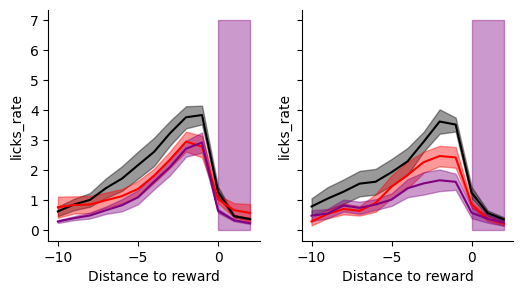

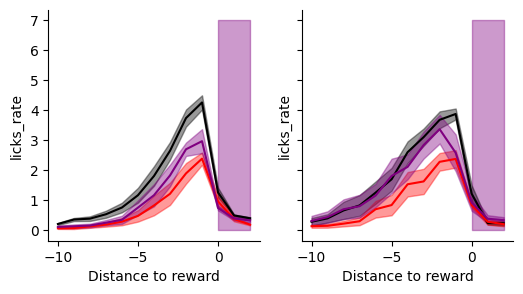

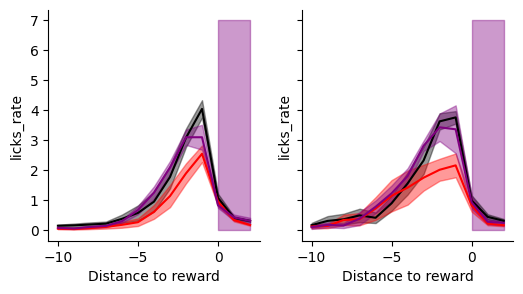

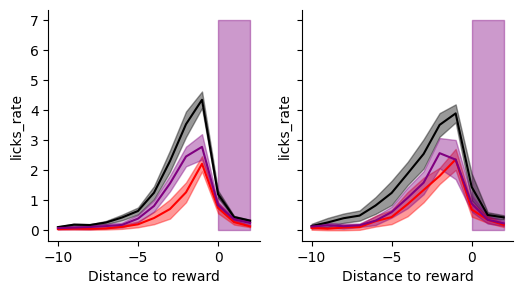

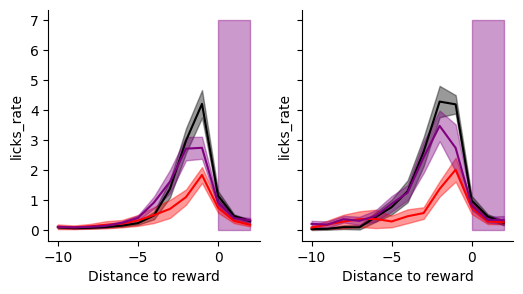

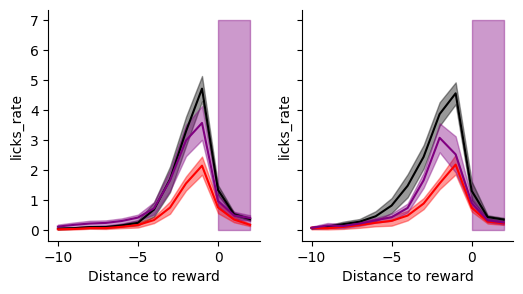

In [51]:
df = make_behavior_dataframe('licks_rate', mean=True)
plot_each_day(df,'licks_rate', maxy=7)

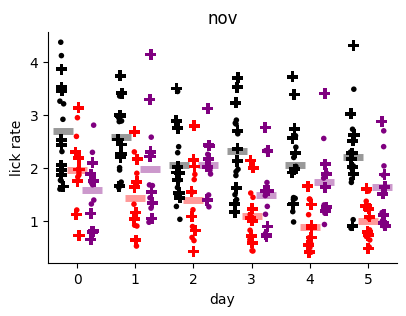

In [54]:


fig,ax = plt.subplots( figsize=[4.5,3], sharey = True)
for i, nov in enumerate(('fam','nov')):
    if nov == 'nov':
        marker = 'P'
        s = 8
    else:
        marker = '.'
        s = 8
    sns.stripplot(data=df.loc[df['ttype']==nov,:],
                x='day',
                y='rzone_dat',
                hue='cond', 
                hue_order=('ctrl', 'ko','sparse'), 
                palette=['black', 'red','purple'],
                dodge=True,
                ax=ax, marker = marker, s=s,
                legend=False)
    


sns.pointplot(data=df,
            x='day',
            y='rzone_dat',
            errorbar=None,
            hue='cond',
            hue_order = ['ctrl', 'ko', 'sparse'],
            dodge = .5,
            palette = ['black', 'red', 'purple'],
            ax=ax,
            linestyles="none",
            marker="_", markersize=15, markeredgewidth=5, legend=False, alpha=.4,
            )
ax.set_title(nov)

# for a in ax:
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylabel('lick rate')


fig.savefig(figdir / "lick_rate_summary.pdf")


0
4467331.1
4467331.2
4467332.1
4467332.2
4467333.1
mCherry6
mCherry7
mCherry8
mCherry9
1
4467331.1
4467331.2
4467332.1
4467332.2
4467333.1
mCherry6
mCherry7
mCherry8
mCherry9
2
4467331.1
4467331.2
4467332.1
4467332.2
4467333.1
mCherry6
mCherry7
mCherry8
mCherry9
3
4467331.1
4467331.2
4467332.1
4467332.2
4467333.1
mCherry6
mCherry7
mCherry8
mCherry9
4
4467331.1
4467331.2
4467332.1
4467332.2
4467333.1
mCherry6
mCherry7
mCherry8
mCherry9
5
4467331.1
4467331.2
4467332.1
4467332.2
4467333.1
mCherry6
mCherry7
mCherry8
mCherry9
0
4467975.1
4467975.2
4467975.3
4467975.4
4467975.5
Cre7
Cre9
1
4467975.1
4467975.2
4467975.3
4467975.4
4467975.5
Cre7
Cre9
2
4467975.1
4467975.2
4467975.3
4467975.4
4467975.5
Cre7
Cre9
3
4467975.1
4467975.2
4467975.3
4467975.4
4467975.5
Cre7
Cre9
4
4467975.1
4467975.2
4467975.3
4467975.4
4467975.5
Cre7
Cre9
5
4467975.1
4467975.2
4467975.3
4467975.4
4467975.5
Cre7
Cre9
0
SparseKO_02
SparseKO_06
SparseKO_08
SparseKO_10
SparseKO_11
SparseKO_13
SparseKO_09
1
SparseKO_02


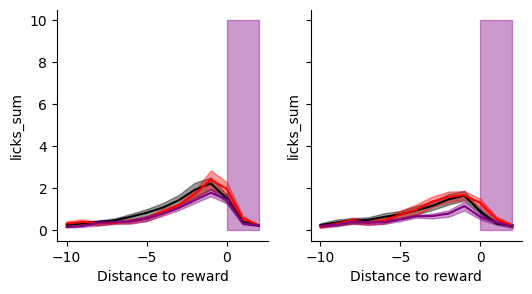

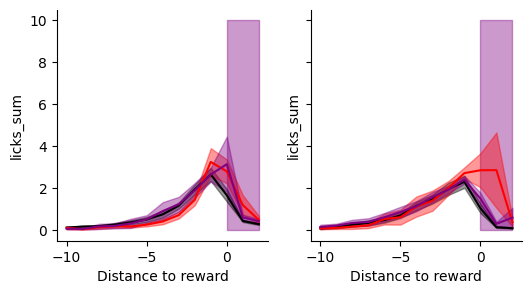

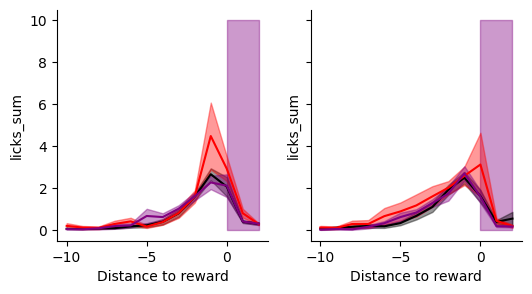

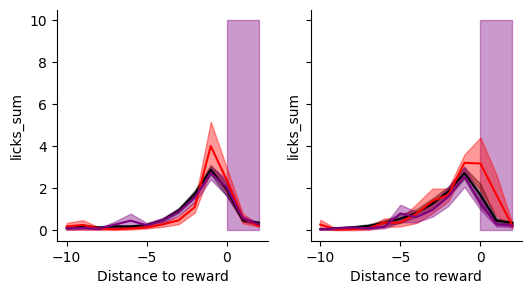

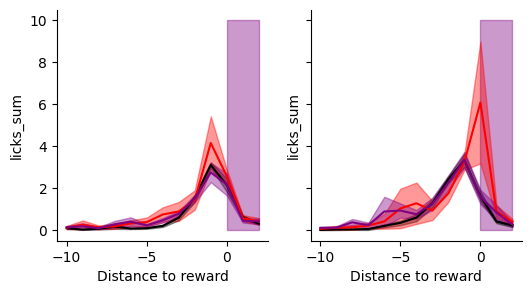

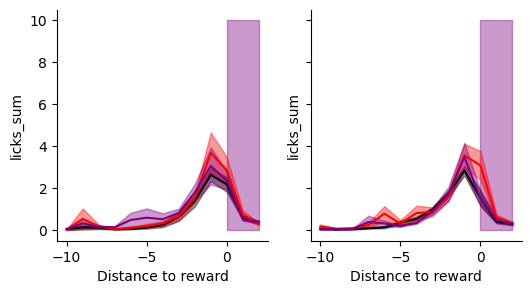

In [7]:
df = make_behavior_dataframe('licks_sum', mean=False)
plot_each_day(df,'licks_sum', maxy=10)

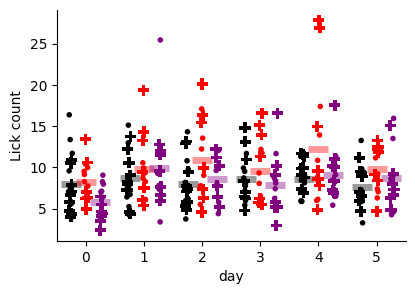

In [8]:
fig,ax = plt.subplots( figsize=[4.5,3], sharey = True)
for i, nov in enumerate(('fam','nov')):
    if nov == 'nov':
        marker = 'P'
        s = 8
    else:
        marker = '.'
        s = 8
    sns.stripplot(data=df.loc[df['ttype']==nov,:],
                x='day',
                y='rzone_dat',
                hue='cond', 
                hue_order=('ctrl', 'ko','sparse'), 
                palette=['black', 'red','purple'],
                dodge=True,
                ax=ax, marker = marker, s=s,
                legend=False)
    


sns.pointplot(data=df,
            x='day',
            y='rzone_dat',
            errorbar=None,
            hue='cond',
            hue_order = ['ctrl', 'ko', 'sparse'],
            dodge = .5,
            palette = ['black', 'red', 'purple'],
            ax=ax,
            linestyles="none",
            marker="_", markersize=15, markeredgewidth=5, legend=False, alpha=.4,
            )
    # ax[i].set_title(nov)

# for a in ax:
ax.set_ylabel('Lick count')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


fig.savefig(figdir / "licks_sum_summary.pdf")


0
4467331.1
4467331.2
4467332.1
4467332.2
4467333.1
mCherry6
mCherry7
mCherry8
mCherry9
1
4467331.1
4467331.2
4467332.1
4467332.2
4467333.1
mCherry6
mCherry7
mCherry8
mCherry9
2
4467331.1
4467331.2
4467332.1
4467332.2
4467333.1
mCherry6
mCherry7
mCherry8
mCherry9
3
4467331.1
4467331.2
4467332.1
4467332.2
4467333.1
mCherry6
mCherry7
mCherry8
mCherry9
4
4467331.1
4467331.2
4467332.1
4467332.2
4467333.1
mCherry6
mCherry7
mCherry8
mCherry9
5
4467331.1
4467331.2
4467332.1
4467332.2
4467333.1
mCherry6
mCherry7
mCherry8
mCherry9
0
4467975.1
4467975.2
4467975.3
4467975.4
4467975.5
Cre7
Cre9
1
4467975.1
4467975.2
4467975.3
4467975.4
4467975.5
Cre7
Cre9
2
4467975.1
4467975.2
4467975.3
4467975.4
4467975.5
Cre7
Cre9
3
4467975.1
4467975.2
4467975.3
4467975.4
4467975.5
Cre7
Cre9
4
4467975.1
4467975.2
4467975.3
4467975.4
4467975.5
Cre7
Cre9
5
4467975.1
4467975.2
4467975.3
4467975.4
4467975.5
Cre7
Cre9
0
SparseKO_02
SparseKO_06
SparseKO_08
SparseKO_10
SparseKO_11
SparseKO_13
SparseKO_09
1
SparseKO_02


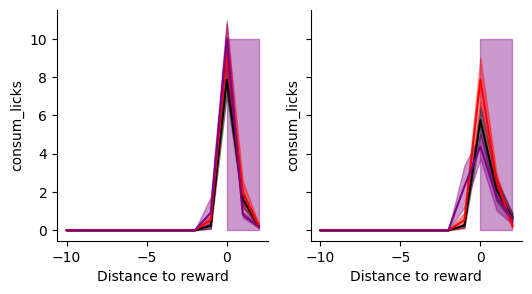

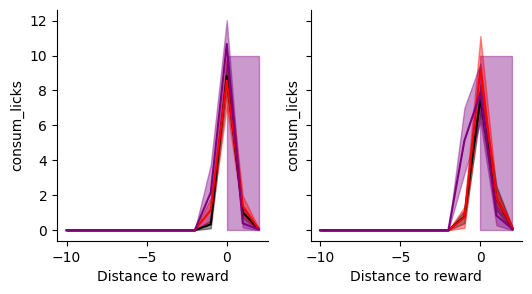

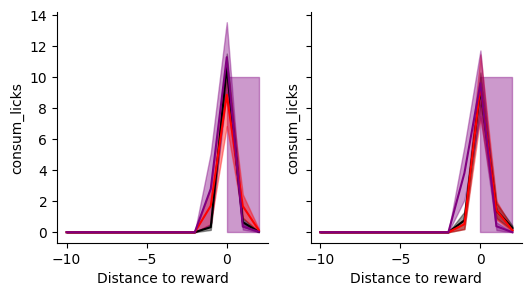

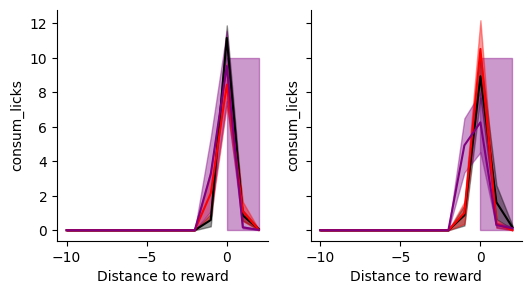

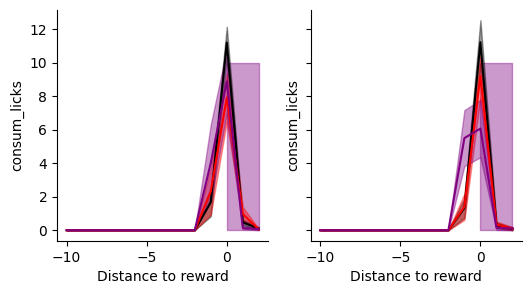

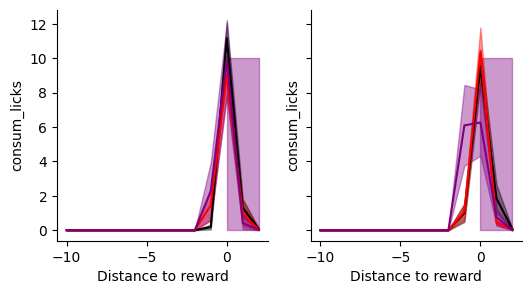

In [9]:
df = make_behavior_dataframe('consum_licks', mean=False)
plot_each_day(df,'consum_licks')

In [10]:


rows = []
x = np.arange(-10,3)
for (cond, mice) in zip(('ctrl', 'ko', 'sparse'), (ctrl_mice, ko_mice, sparse_mice)):
    for day in range(6):
        
        print(day)
        for mouse in mice:

            if mouse == 'SparseKO_09' and day==2:
                continue
            print(mouse)
            sess = stx.utilities.load_vr_day(mouse, day,verbose = False, pkldir = '/mnt/BigDisk/YMaze_VR_Pkls/', trial_mat_keys=['licks', 
                                                                                                                                'licks_sum', 
                                                                                                                                'nonconsum_licks', 
                                                                                                                                'consum_licks', 
                                                                                                                                'licks_rate', 'speed'])
            # if se
            # sess.novel_arm = stx.ymaze_sess_deets['']

            bin_edges = sess.trial_matrices['bin_edges']
            right_rzone_front = np.argwhere((sess.rzone_late['tfront']<=bin_edges[1:])*(sess.rzone_late['tfront']>=bin_edges[:-1]))[0][0]
            left_rzone_front = np.argwhere((sess.rzone_early['tfront']<=bin_edges[1:])*(sess.rzone_early['tfront']>=bin_edges[:-1]))[0][0]

            if sess.novel_arm==-1:
                rzone_nov = left_rzone_front
                rzone_fam = right_rzone_front
            else:
                rzone_nov = right_rzone_front
                rzone_fam = left_rzone_front

            for ttype in ('fam', 'nov'):
                
                if ttype == 'nov':
                    trial_mask = sess.trial_info["LR"] == sess.novel_arm
                    rzone = rzone_nov
                else:
                    trial_mask = sess.trial_info["LR"] != sess.novel_arm
                    rzone = rzone_fam

                
                licks = sess.trial_matrices['consum_licks'][trial_mask,:]
                
                rows.append({'cond': cond,
                            'mouse': mouse,
                            'day': day,
                            'ttype': ttype,
                            'licks': np.nansum(licks, axis=1).mean(axis=0),
                            })
df = pd.DataFrame(rows)
                    
                

0
4467331.1
4467331.2
4467332.1
4467332.2
4467333.1
mCherry6
mCherry7
mCherry8
mCherry9
1
4467331.1
4467331.2
4467332.1
4467332.2
4467333.1
mCherry6
mCherry7
mCherry8
mCherry9
2
4467331.1
4467331.2
4467332.1
4467332.2
4467333.1
mCherry6
mCherry7
mCherry8
mCherry9
3
4467331.1
4467331.2
4467332.1
4467332.2
4467333.1
mCherry6
mCherry7
mCherry8
mCherry9
4
4467331.1
4467331.2
4467332.1
4467332.2
4467333.1
mCherry6
mCherry7
mCherry8
mCherry9
5
4467331.1
4467331.2
4467332.1
4467332.2
4467333.1
mCherry6
mCherry7
mCherry8
mCherry9
0
4467975.1
4467975.2
4467975.3
4467975.4
4467975.5
Cre7
Cre9
1
4467975.1
4467975.2
4467975.3
4467975.4
4467975.5
Cre7
Cre9
2
4467975.1
4467975.2
4467975.3
4467975.4
4467975.5
Cre7
Cre9
3
4467975.1
4467975.2
4467975.3
4467975.4
4467975.5
Cre7
Cre9
4
4467975.1
4467975.2
4467975.3
4467975.4
4467975.5
Cre7
Cre9
5
4467975.1
4467975.2
4467975.3
4467975.4
4467975.5
Cre7
Cre9
0
SparseKO_02
SparseKO_06
SparseKO_08
SparseKO_10
SparseKO_11
SparseKO_13
SparseKO_09
1
SparseKO_02


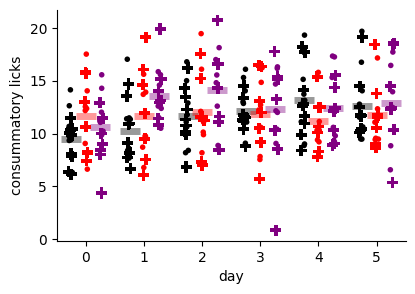

In [11]:
fig,ax = plt.subplots( figsize=[4.5,3], sharey = True)
for i, nov in enumerate(('fam','nov')):
    if nov == 'nov':
        marker = 'P'
        s = 8
    else:
        marker = '.'
        s = 8
    sns.stripplot(data=df.loc[df['ttype']==nov,:],
                x='day',
                y='licks',
                hue='cond', 
                hue_order=('ctrl', 'ko','sparse'), 
                palette=['black', 'red','purple'],
                dodge=True,
                ax=ax, marker = marker, s=s,
                legend=False)
    


sns.pointplot(data=df,
            x='day',
            y='licks',
            errorbar=None,
            hue='cond',
            hue_order = ['ctrl', 'ko', 'sparse'],
            dodge = .5,
            palette = ['black', 'red', 'purple'],
            ax=ax,
            linestyles="none",
            marker="_", markersize=15, markeredgewidth=5, legend=False, alpha=.4,
            )
    # ax[i].set_title(nov)

# for a in ax:
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylabel('consummatory licks')


fig.savefig(figdir / "consum_licks_summary.pdf")


0
4467331.1
4467331.2
4467332.1
4467332.2
4467333.1
mCherry6
mCherry7
mCherry8
mCherry9
1
4467331.1
4467331.2
4467332.1
4467332.2
4467333.1
mCherry6
mCherry7
mCherry8
mCherry9
2
4467331.1
4467331.2
4467332.1
4467332.2
4467333.1
mCherry6
mCherry7
mCherry8
mCherry9
3
4467331.1
4467331.2
4467332.1
4467332.2
4467333.1
mCherry6
mCherry7
mCherry8
mCherry9
4
4467331.1
4467331.2
4467332.1
4467332.2
4467333.1
mCherry6
mCherry7
mCherry8
mCherry9
5
4467331.1
4467331.2
4467332.1
4467332.2
4467333.1
mCherry6
mCherry7
mCherry8
mCherry9
0
4467975.1
4467975.2
4467975.3
4467975.4
4467975.5
Cre7
Cre9
1
4467975.1
4467975.2
4467975.3
4467975.4
4467975.5
Cre7
Cre9
2
4467975.1
4467975.2
4467975.3
4467975.4
4467975.5
Cre7
Cre9
3
4467975.1
4467975.2
4467975.3
4467975.4
4467975.5
Cre7
Cre9
4
4467975.1
4467975.2
4467975.3
4467975.4
4467975.5
Cre7
Cre9
5
4467975.1
4467975.2
4467975.3
4467975.4
4467975.5
Cre7
Cre9
0
SparseKO_02
SparseKO_06
SparseKO_08
SparseKO_10
SparseKO_11
SparseKO_13
SparseKO_09
1
SparseKO_02


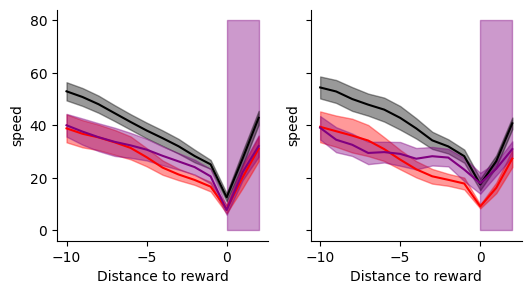

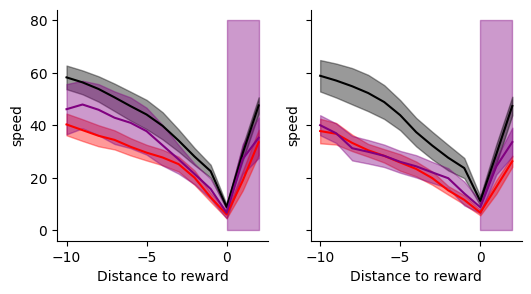

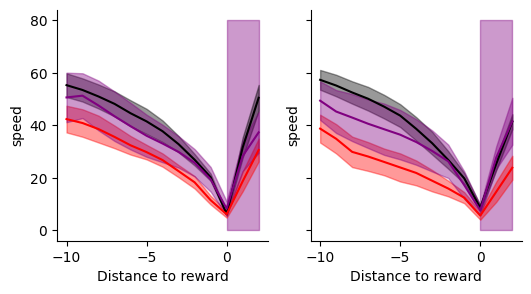

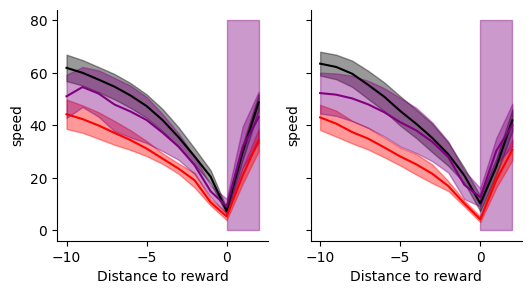

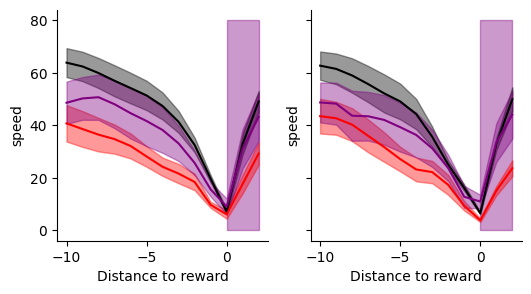

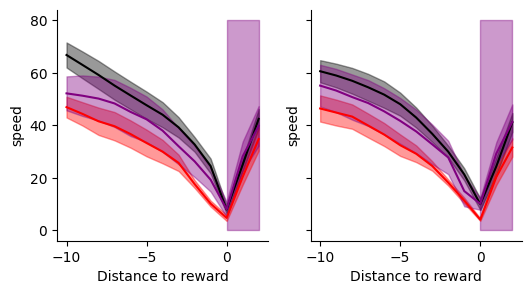

In [12]:
df = make_behavior_dataframe('speed', mean=True)
plot_each_day(df,'speed',maxy=80)

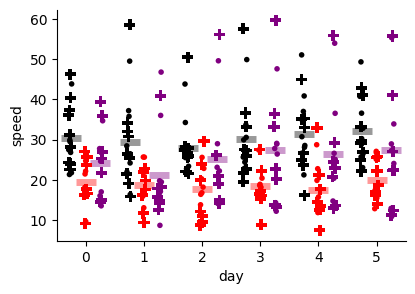

In [13]:
fig,ax = plt.subplots( figsize=[4.5,3], sharey = True)
for i, nov in enumerate(('fam','nov')):
    if nov == 'nov':
        marker = 'P'
        s = 8
    else:
        marker = '.'
        s = 8
    sns.stripplot(data=df.loc[df['ttype']==nov,:],
                x='day',
                y='rzone_dat',
                hue='cond', 
                hue_order=('ctrl', 'ko','sparse'), 
                palette=['black', 'red','purple'],
                dodge=True,
                ax=ax, marker = marker, s=s,
                legend=False)
    


sns.pointplot(data=df,
            x='day',
            y='rzone_dat',
            errorbar=None,
            hue='cond',
            hue_order = ['ctrl', 'ko', 'sparse'],
            dodge = .5,
            palette = ['black', 'red', 'purple'],
            ax=ax,
            linestyles="none",
            marker="_", markersize=15, markeredgewidth=5, legend=False, alpha=.4,
            )
    # ax[i].set_title(nov)

# for a in ax:
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylabel('speed')


fig.savefig(figdir / "speed_summary.pdf")


In [48]:
rows = []
for (cond, mice) in zip(('ctrl', 'ko', 'sparse'), (ctrl_mice, ko_mice, sparse_mice)):
    for day in range(6):
        
        print(day)
        for mouse in mice:

            if mouse == 'SparseKO_09' and day==2:
                continue
            print(mouse)
            sess = stx.utilities.load_vr_day(mouse, day,verbose = False, pkldir = '/mnt/BigDisk/YMaze_VR_Pkls/', trial_mat_keys=['licks', 
                                                                                                                                'licks_sum', 
                                                                                                                                'nonconsum_licks', 
                                                                                                                                'consum_licks', 
                                                                                                                                'licks_rate', 'speed'])
            # if se
            # sess.novel_arm = stx.ymaze_sess_deets['']

            bin_edges = sess.trial_matrices['bin_edges']
            right_rzone_front = np.argwhere((sess.rzone_late['tfront']<=bin_edges[1:])*(sess.rzone_late['tfront']>=bin_edges[:-1]))[0][0]
            left_rzone_front = np.argwhere((sess.rzone_early['tfront']<=bin_edges[1:])*(sess.rzone_early['tfront']>=bin_edges[:-1]))[0][0]

            if sess.novel_arm==-1:
                rzone_nov = left_rzone_front
                rzone_fam = right_rzone_front
            else:
                rzone_nov = right_rzone_front
                rzone_fam = left_rzone_front

            for ttype in ('fam', 'nov'):
                
                if ttype == 'nov':
                    trial_mask = sess.trial_info["LR"] == sess.novel_arm
                    rzone = rzone_nov
                else:
                    trial_mask = sess.trial_info["LR"] != sess.novel_arm
                    rzone = rzone_fam

                
                cv = sp.stats.variation(sess.trial_matrices['speed'][trial_mask,:],axis=0, nan_policy='omit')
                rzone_plot_vec = cv[rzone-10:rzone+3]
                # print(cv)
                rows.append({'cond': cond,
                            'mouse': mouse,
                            'day': day,
                            'ttype': ttype,
                            'rzone_dat': cv[rzone-5:rzone+1].mean(),
                            'rzone_plot_vec': rzone_plot_vec,
                            })
df = pd.DataFrame(rows)

0
4467331.1
4467331.2
4467332.1
4467332.2
4467333.1
mCherry6
mCherry7
mCherry8
mCherry9
1
4467331.1
4467331.2
4467332.1
4467332.2
4467333.1
mCherry6
mCherry7
mCherry8
mCherry9
2
4467331.1
4467331.2
4467332.1
4467332.2
4467333.1
mCherry6
mCherry7
mCherry8
mCherry9
3
4467331.1
4467331.2
4467332.1
4467332.2
4467333.1
mCherry6
mCherry7
mCherry8
mCherry9
4
4467331.1
4467331.2
4467332.1
4467332.2
4467333.1
mCherry6
mCherry7
mCherry8
mCherry9
5
4467331.1
4467331.2
4467332.1
4467332.2
4467333.1
mCherry6
mCherry7
mCherry8
mCherry9
0
4467975.1
4467975.2
4467975.3
4467975.4
4467975.5
Cre7
Cre9
1
4467975.1
4467975.2
4467975.3
4467975.4
4467975.5
Cre7
Cre9
2
4467975.1
4467975.2
4467975.3
4467975.4
4467975.5
Cre7
Cre9
3
4467975.1
4467975.2
4467975.3
4467975.4
4467975.5
Cre7
Cre9
4
4467975.1
4467975.2
4467975.3
4467975.4
4467975.5
Cre7
Cre9
5
4467975.1
4467975.2
4467975.3
4467975.4
4467975.5
Cre7
Cre9
0
SparseKO_02
SparseKO_06
SparseKO_08
SparseKO_10
SparseKO_11
SparseKO_13
SparseKO_09
1
SparseKO_02


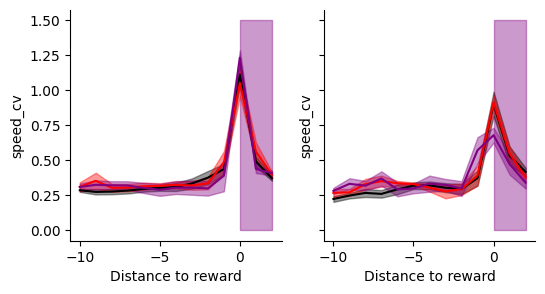

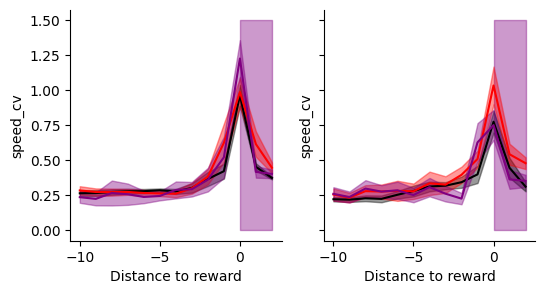

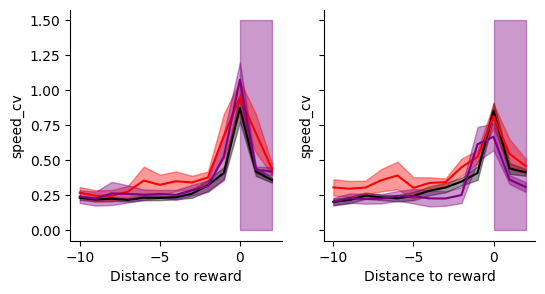

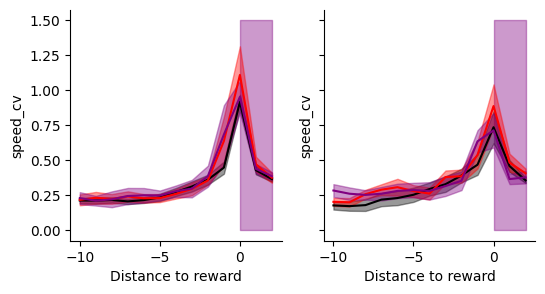

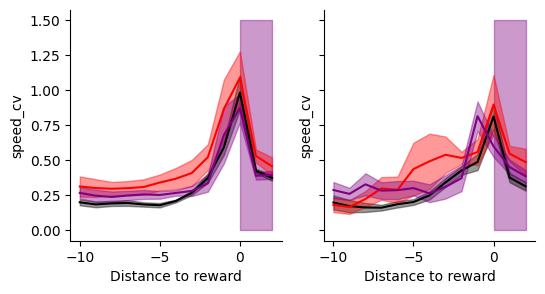

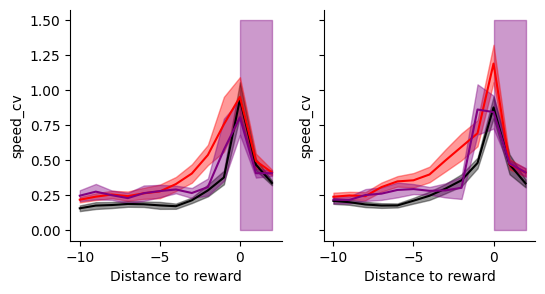

In [50]:
plot_each_day(df,'speed_cv',maxy=1.5)

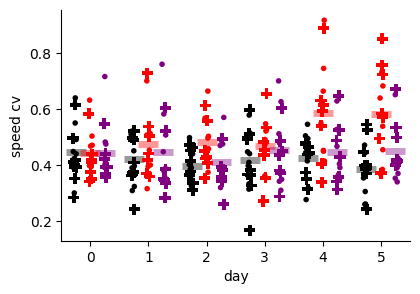

In [29]:
fig,ax = plt.subplots( figsize=[4.5,3], sharey = True)
for i, nov in enumerate(('fam','nov')):
    if nov == 'nov':
        marker = 'P'
        s = 8
    else:
        marker = '.'
        s = 8
    sns.stripplot(data=df.loc[df['ttype']==nov,:],
                x='day',
                y='speed_cv',
                hue='cond', 
                hue_order=('ctrl', 'ko','sparse'), 
                palette=['black', 'red','purple'],
                dodge=True,
                ax=ax, marker = marker, s=s,
                legend=False)
    


sns.pointplot(data=df,
            x='day',
            y='speed_cv',
            errorbar=None,
            hue='cond',
            hue_order = ['ctrl', 'ko', 'sparse'],
            dodge = .5,
            palette = ['black', 'red', 'purple'],
            ax=ax,
            linestyles="none",
            marker="_", markersize=15, markeredgewidth=5, legend=False, alpha=.4,
            )
    # ax[i].set_title(nov)

# for a in ax:
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylabel('speed cv')


fig.savefig(figdir / "speed_summary.pdf")


{'date': '19_10_2021', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 5, 'novel_arm': 1, 'ravel_ind': 5}


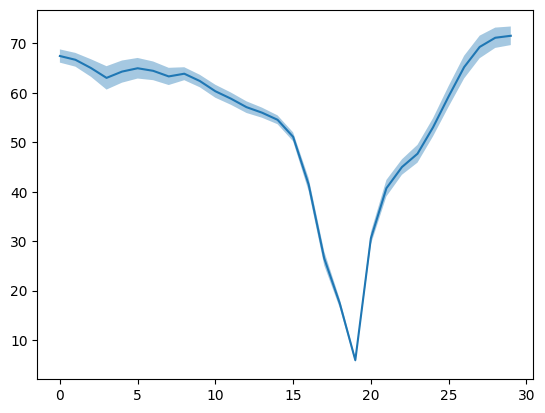

In [44]:
sess = u.load_vr_day(ctrl_mice[5],5, pkldir = '/mnt/BigDisk/YMaze_VR_Pkls/')

fig, ax = plt.subplots()

tmat = sess.trial_matrices['speed'][sess.trial_info['LR']!=sess.novel_arm,:]
mu, sem = np.nanmean(tmat, axis=0), sp.stats.sem(tmat, axis=0, nan_policy='omit')

x= np.arange(30)
ax.plot(x,mu)
ax.fill_between(x, mu-sem, mu+sem, alpha=.4)


In [90]:
df['rzone_licks_rank'] = df['rzone_licks'].rank()




In [91]:
aov = pg.mixed_anova(data = df.loc[(df['ttype']=='fam')*df['cond'].isin(('ctrl','ko'))], subject='mouse', 
                     within='day', between='cond', dv='rzone_licks_rank')

aov

,Source,SS,DF1,DF2,MS,F,p-unc,np2,eps
0,cond,43441.084821,1,14,43441.084821,2.609557,0.128526,0.157112,NaN
1,day,3569.020833,5,70,713.804167,0.254528,0.936164,0.017856,0.817285
2,Interaction,9095.582341,5,70,1819.116468,0.648661,0.663418,0.044281,NaN


In [92]:
aov = pg.mixed_anova(data = df.loc[(df['ttype']=='nov')*df['cond'].isin(('ctrl','ko'))], subject='mouse', 
                     within='day', between='cond', dv='rzone_licks_rank')

aov

,Source,SS,DF1,DF2,MS,F,p-unc,np2,eps
0,cond,68166.785756,1,14,68166.785756,3.921028,0.067689,0.218795,NaN
1,day,63980.731771,5,70,12796.146354,3.274264,0.010284,0.189546,0.61314
2,Interaction,6679.465980,5,70,1335.893196,0.341827,0.885809,0.023834,NaN


In [93]:
pg.pairwise_tests(data=df.loc[df['cond'].isin(('ctrl','ko'))], 
                  subject='mouse', 
                  within='day', 
                  between='cond', 
                  dv='rzone_licks', 
                  parametric=False, padjust='holm', within_first=True)

,Contrast,day,A,B,Paired,Parametric,U-val,W-val,alternative,p-unc,p-corr,p-adjust,hedges
0,day,-,0,1,True,False,NaN,32.0,two-sided,0.065399,0.915588,holm,-0.472028
1,day,-,0,2,True,False,NaN,39.0,two-sided,0.143860,1.000000,holm,-0.433712
2,day,-,0,3,True,False,NaN,46.0,two-sided,0.274445,1.000000,holm,-0.498996
3,day,-,0,4,True,False,NaN,22.0,two-sided,0.015503,0.232544,holm,-0.839832
4,day,-,0,5,True,False,NaN,44.0,two-sided,0.231201,1.000000,holm,-0.436209
5,day,-,1,2,True,False,NaN,64.0,two-sided,0.860260,1.000000,holm,-0.062456
6,day,-,1,3,True,False,NaN,65.0,two-sided,0.899933,1.000000,holm,-0.026757
7,day,-,1,4,True,False,NaN,44.0,two-sided,0.231201,1.000000,holm,-0.387573
8,day,-,1,5,True,False,NaN,51.0,two-sided,0.403748,1.000000,holm,0.075179
9,day,-,2,3,True,False,NaN,53.0,two-sided,0.463745,1.000000,holm,0.040374


In [94]:
pg.pairwise_tests(data=df.loc[df['ttype']=='fam'], 
                  subject='mouse', 
                  within='day', 
                  between='cond', 
                  dv='rzone_licks', 
                  parametric=False, padjust='holm', within_first=True)

,Contrast,day,A,B,Paired,Parametric,U-val,W-val,alternative,p-unc,p-corr,p-adjust,hedges
0,day,-,0,1,True,False,NaN,91.0,two-sided,0.261520,1.000000,holm,-0.327812
1,day,-,0,2,True,False,NaN,94.0,two-sided,0.305309,1.000000,holm,-0.284193
2,day,-,0,3,True,False,NaN,95.0,two-sided,0.320883,1.000000,holm,-0.210323
3,day,-,0,4,True,False,NaN,75.0,two-sided,0.098411,1.000000,holm,-0.375779
4,day,-,0,5,True,False,NaN,99.0,two-sided,0.388045,1.000000,holm,-0.197654
5,day,-,1,2,True,False,NaN,123.0,two-sided,0.923966,1.000000,holm,0.050955
6,day,-,1,3,True,False,NaN,110.0,two-sided,0.610152,1.000000,holm,0.190891
7,day,-,1,4,True,False,NaN,126.0,two-sided,1.000000,1.000000,holm,0.040777
8,day,-,1,5,True,False,NaN,100.0,two-sided,0.406033,1.000000,holm,0.164225
9,day,-,2,3,True,False,NaN,89.0,two-sided,0.234762,1.000000,holm,0.137730


In [95]:
pg.pairwise_tests(data=df.loc[df['ttype']=='nov'], 
                  subject='mouse', 
                  within='day', 
                  between='cond', 
                  dv='rzone_licks', 
                  parametric=False, padjust='holm', within_first=True)

,Contrast,day,A,B,Paired,Parametric,U-val,W-val,alternative,p-unc,p-corr,p-adjust,hedges
0,day,-,0,1,True,False,NaN,17.0,two-sided,0.000099,0.001382,holm,-1.061408
1,day,-,0,2,True,False,NaN,27.0,two-sided,0.000593,0.007705,holm,-0.894975
2,day,-,0,3,True,False,NaN,38.0,two-sided,0.007443,0.081874,holm,-0.884101
3,day,-,0,4,True,False,NaN,15.0,two-sided,0.000065,0.000980,holm,-1.264398
4,day,-,0,5,True,False,NaN,33.0,two-sided,0.001455,0.017458,holm,-1.072138
5,day,-,1,2,True,False,NaN,111.0,two-sided,0.632729,1.000000,holm,0.048976
6,day,-,1,3,True,False,NaN,121.0,two-sided,0.873604,1.000000,holm,0.074265
7,day,-,1,4,True,False,NaN,89.0,two-sided,0.234762,1.000000,holm,-0.374841
8,day,-,1,5,True,False,NaN,102.0,two-sided,0.443407,1.000000,holm,0.118885
9,day,-,2,3,True,False,NaN,126.0,two-sided,1.000000,1.000000,holm,0.022907


In [96]:
import statsmodels.formula.api as smf
tmp_df = df.loc[df['cond'].isin(('ctrl', 'ko'))]

mdl = smf.mixedlm('rzone_licks_rank ~ C(cond) * C(ttype) + C(day) ', tmp_df, groups=tmp_df['mouse'])
res = mdl.fit()
res.summary()


<class 'statsmodels.iolib.summary2.Summary'>
"""
                   Mixed Linear Model Regression Results
============================================================================
Model:                  MixedLM     Dependent Variable:     rzone_licks_rank
No. Observations:       192         Method:                 REML            
No. Groups:             16          Scale:                  3633.3101       
Min. group size:        12          Log-Likelihood:         -1039.2514      
Max. group size:        12          Converged:              Yes             
Mean group size:        12.0                                                
----------------------------------------------------------------------------
                               Coef.   Std.Err.   z    P>|z|  [0.025  0.975]
----------------------------------------------------------------------------
Intercept                       94.685   19.397  4.882 0.000  56.668 132.702
C(cond)[T.ko]                   42.881   25.371  1.690 0.091  -6.845  92.607
C(ttype)[T.nov]                 -1.287   11.600 -0.111 0.912 -24.023  21.449
C(day)[T.1]                     28.016   15.069  1.859 0.063  -1.520  57.551
C(day)[T.2]                     20.203   15.069  1.341 0.180  -9.332  49.738
C(day)[T.3]                     27.828   15.069  1.847 0.065  -1.707  57.363
C(day)[T.4]                     49.547   15.069  3.288 0.001  20.012  79.082
C(day)[T.5]                     27.297   15.069  1.811 0.070  -2.238  56.832
C(cond)[T.ko]:C(ttype)[T.nov]   10.835   17.538  0.618 0.537 -23.539  45.209
Group Var                     1928.944   14.562                             
============================================================================

"""

In [29]:
res.wald_test_terms()

/home/mplitt/mambaforge/envs/stx3/lib/python3.10/site-packages/statsmodels/base/model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(


<class 'statsmodels.stats.contrast.WaldTestResults'>
                                    chi2                 P>chi2  df constraint
Intercept         [[123.51979423448311]]  1.073103826403835e-28              1
C(cond)            [[9.280366373780387]]  0.0023162309619335765              1
C(ttype)          [[2.4256137591542144]]    0.11936648161007381              1
C(day)             [[54.69399927263712]]  1.508946304622511e-10              5
C(cond):C(ttype)  [[0.6004816463187079]]    0.43839431518251726              1

Shapiro-Wilk: W=0.993, p=0.463
D'Agostino: χ²=2.361, p=0.307


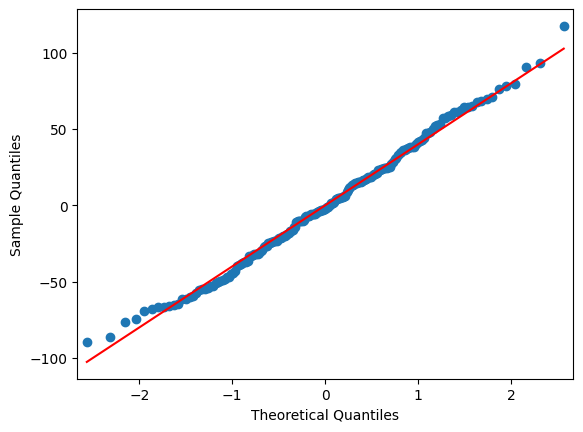

In [30]:
import statsmodels.api as sm
from scipy.stats import shapiro, normaltest, anderson
fig = sm.qqplot(res.resid, line ='s')

# Shapiro-Wilk test (good for small–moderate n)
shapiro_test = shapiro(res.resid)
print(f"Shapiro-Wilk: W={shapiro_test.statistic:.3f}, p={shapiro_test.pvalue:.3g}")

# D’Agostino and Pearson omnibus test (good for larger n)
dagostino_test = normaltest(res.resid)
print(f"D'Agostino: χ²={dagostino_test.statistic:.3f}, p={dagostino_test.pvalue:.3g}")

In [31]:
import pickle

with open('/home/mplitt/shuffle_pkls/licks_sum_mixedlm_shuffle.pkl', 'rb') as file:
    res_dict = pickle.load(file)

In [26]:
res_dict.keys()

dict_keys(['rzone_licks', 'rzone_licks_rank'])

In [27]:
for stat in res_dict.keys():
    coef = res_dict[stat]['genotype coef.']
    shuff_coef = res_dict[stat]['shuffle genotype coef.']

    p = (1.*(coef<shuff_coef)).sum()/shuff_coef.shape[0]
    p = np.minimum(p, 1-p)
    print(f"{stat} : p={p}")

rzone_licks : p=0.05139860139860142
rzone_licks_rank : p=0.048164335664335645
